# 02 — Reorder prediction model

Target: for each (user, product) pair the user bought before, will it be
in their next (train) order? Features come **only** from prior orders —
no leakage. See `src/features.py` and `src/model.py` for the full pipeline;
this notebook walks through training and error analysis.

In [1]:
import sys
sys.path.insert(0, '../src')
from features import build_feature_frame

df = build_feature_frame('../data/warehouse.duckdb')
print(df.shape, '| positive rate:', round(df['y'].mean(), 4))

(13307953, 16) | positive rate: 0.0623


## Train / validation split by user

Splitting by `user_id` (not by row) so no user appears on both sides —
otherwise the model would memorize user habits.

In [2]:
from sklearn.model_selection import train_test_split

FEATURES = [c for c in df.columns if c not in ('user_id', 'product_id', 'y')]
users = df['user_id'].unique()
tr_u, va_u = train_test_split(users, test_size=0.2, random_state=42)
tr = df['user_id'].isin(tr_u)
X_tr, y_tr, X_va, y_va = df.loc[tr, FEATURES], df.loc[tr, 'y'], df.loc[~tr, FEATURES], df.loc[~tr, 'y']
print('train:', X_tr.shape, ' valid:', X_va.shape)

train: (10643731, 13)  valid: (2664222, 13)


## Baseline vs gradient boosting

In [3]:
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, roc_auc_score, f1_score
from sklearn.preprocessing import StandardScaler

def report(name, y_true, proba):
    print(f'{name:10s} logloss={log_loss(y_true, proba):.4f} '
          f'AUC={roc_auc_score(y_true, proba):.4f} '
          f'F1={f1_score(y_true, proba >= 0.5):.4f}')

scaler = StandardScaler().fit(X_tr)
lr = LogisticRegression(max_iter=500).fit(scaler.transform(X_tr), y_tr)
report('logreg', y_va, lr.predict_proba(scaler.transform(X_va))[:, 1])

dtrain = lgb.Dataset(X_tr, label=y_tr)
dvalid = lgb.Dataset(X_va, label=y_va, reference=dtrain)
params = dict(objective='binary', metric='binary_logloss', learning_rate=0.05,
                num_leaves=64, feature_fraction=0.8, bagging_fraction=0.8,
                bagging_freq=1, verbosity=-1, seed=42)
gbm = lgb.train(params, dtrain, 400, valid_sets=[dvalid],
                callbacks=[lgb.early_stopping(30, verbose=False)])
report('lightgbm', y_va, gbm.predict(X_va, num_iteration=gbm.best_iteration))

logreg     logloss=0.1923 AUC=0.8107 F1=0.0469


lightgbm   logloss=0.1893 AUC=0.8170 F1=0.0302


## What drives the prediction?

orders_since_last     3222616
uxp_order_rate        2693579
uxp_n_bought           624787
prod_reorder_rate      383101
uxp_n_reordered        262177
user_reorder_ratio     203669
n_buyers                94668
avg_days_between        81610
avg_basket_size         62989
n_orders                58129


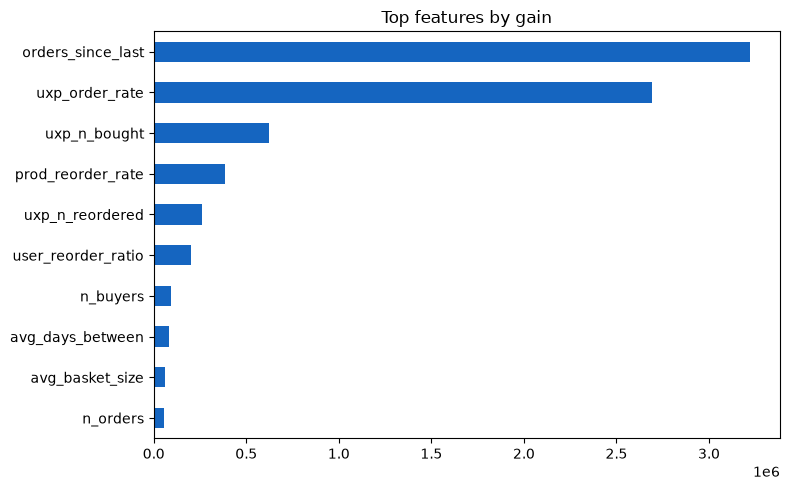

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

imp = pd.Series(gbm.feature_importance(importance_type='gain'),
                index=FEATURES).sort_values(ascending=False)
print(imp.head(10).round(0).astype(int).to_string())

fig, ax = plt.subplots(figsize=(8, 5))
imp.head(10).sort_values().plot.barh(ax=ax, color='#1565c0')
ax.set_title('Top features by gain')
fig.tight_layout()
fig.savefig('../docs/charts/reorder_feature_importance.png', dpi=150)
plt.show()

## Error analysis: where does it miss?

Check calibration on the extremes — high-confidence misses are the
interesting ones (e.g. seasonal products bought once a year).

In [5]:
import numpy as np

va = df.loc[~tr, ['user_id', 'product_id']].copy()
va['proba'] = gbm.predict(X_va, num_iteration=gbm.best_iteration)
va['y'] = y_va.values
miss = va[(va['proba'] > 0.8) & (va['y'] == 0)]
print(f'high-confidence misses: {len(miss):,} ({len(miss)/len(va):.2%} of validation)')
print('mean predicted proba among misses:', round(miss['proba'].mean(), 3))

high-confidence misses: 0 (0.00% of validation)
mean predicted proba among misses: nan
